In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
import datetime 
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection  import train_test_split
from tensorflow.keras import Sequential 
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM 
from sklearn.metrics import r2_score


In [2]:
data  = pd.read_csv('Google_Stock_Price_Train.csv',thousands=',') 
data

,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,7380500
1,1/4/2012,331.27,333.87,329.08,666.45,5749400
2,1/5/2012,329.83,330.75,326.89,657.21,6590300
3,1/6/2012,328.34,328.77,323.68,648.24,5405900
4,1/9/2012,322.04,322.29,309.46,620.76,11688800
...,...,...,...,...,...,...
1253,12/23/2016,790.90,792.74,787.28,789.91,623400
1254,12/27/2016,790.68,797.86,787.66,791.55,789100
1255,12/28/2016,793.70,794.23,783.20,785.05,1153800
1256,12/29/2016,783.33,785.93,778.92,782.79,744300


Text(0, 0.5, 'Stock Volume')

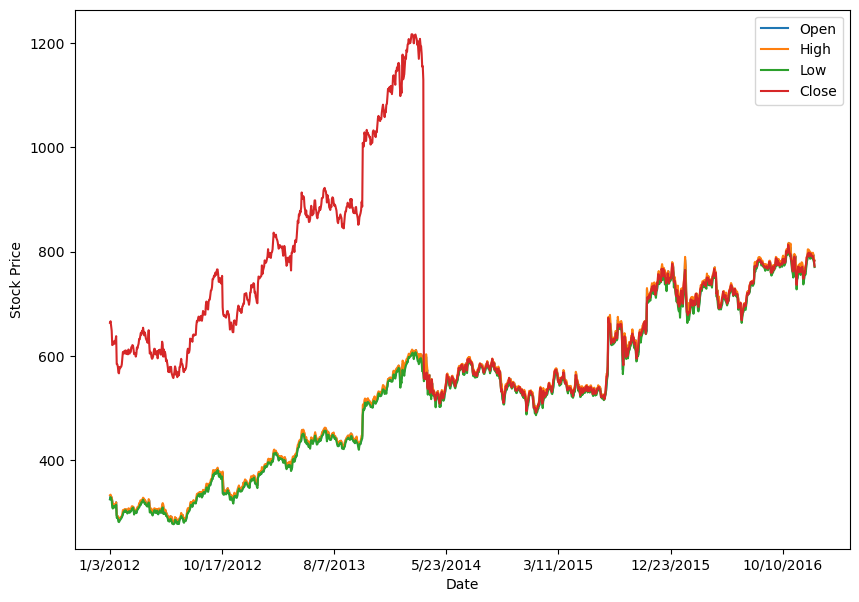

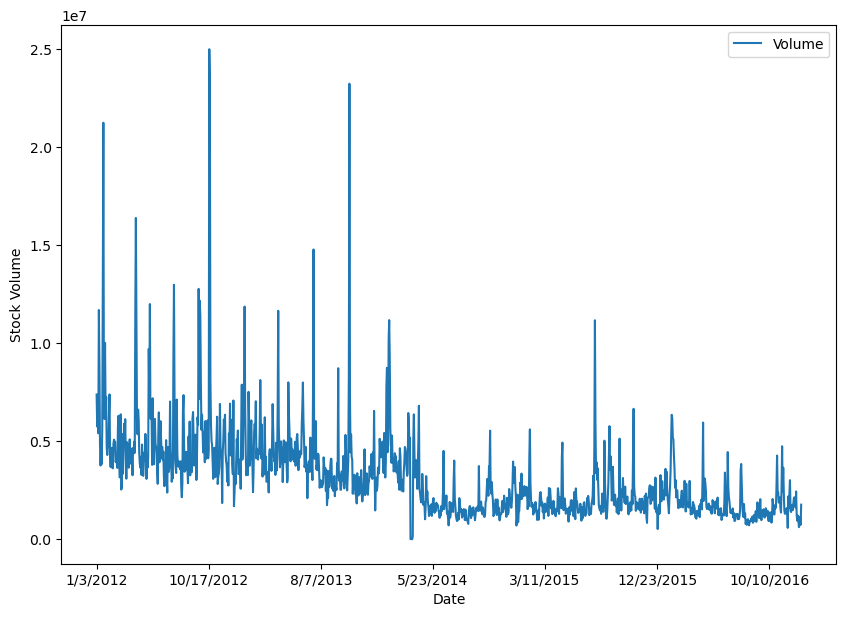

In [3]:
ax1 = data.plot(x="Date", y=["Open", "High", "Low", "Close"], figsize=(10,7))
ax1.set_ylabel("Stock Price")

ax2 = data.plot(x="Date", y=["Volume"], figsize=(10,7))
ax2.set_ylabel("Stock Volume")

In [4]:
data.isna().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

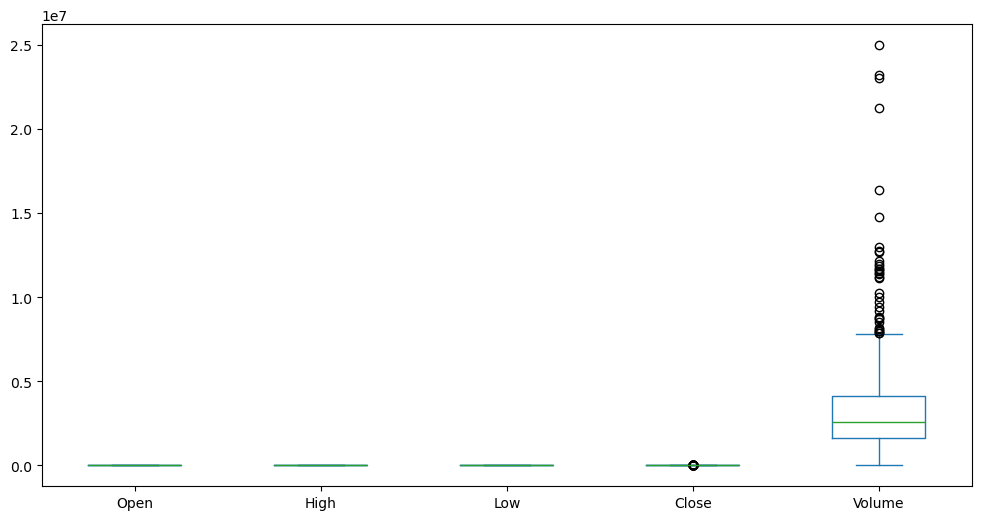

In [5]:
data[['Open','High','Low','Close','Volume']].plot(kind='box', layout=(1,5), figsize=(12,6))
plt.show()

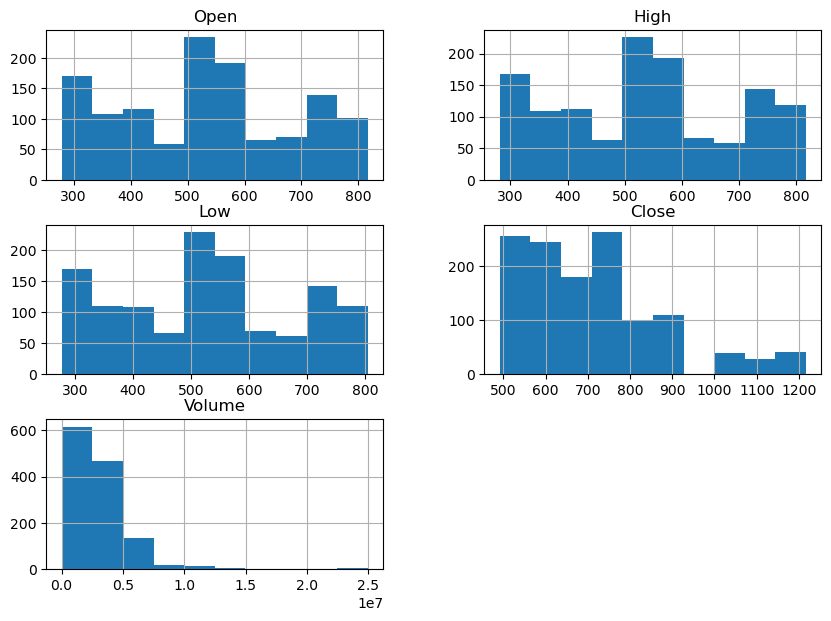

In [6]:
data.hist(figsize=(10,7)) 
plt.show()

In [7]:
scaler = MinMaxScaler()
data_without_date = data.drop("Date", axis=1)
scaled_data  = pd.DataFrame(scaler.fit_transform(data_without_date))

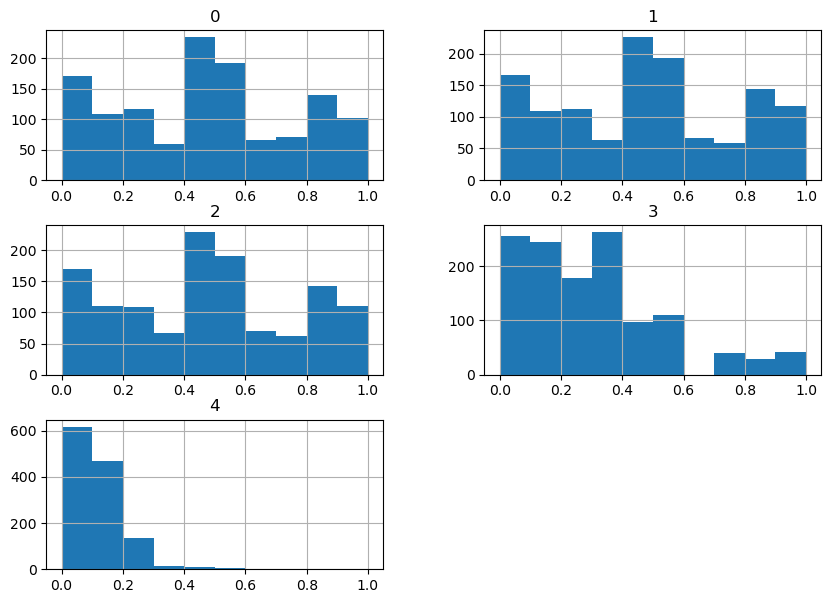

In [8]:
scaled_data.hist(figsize=(10,7)) 
plt.show()

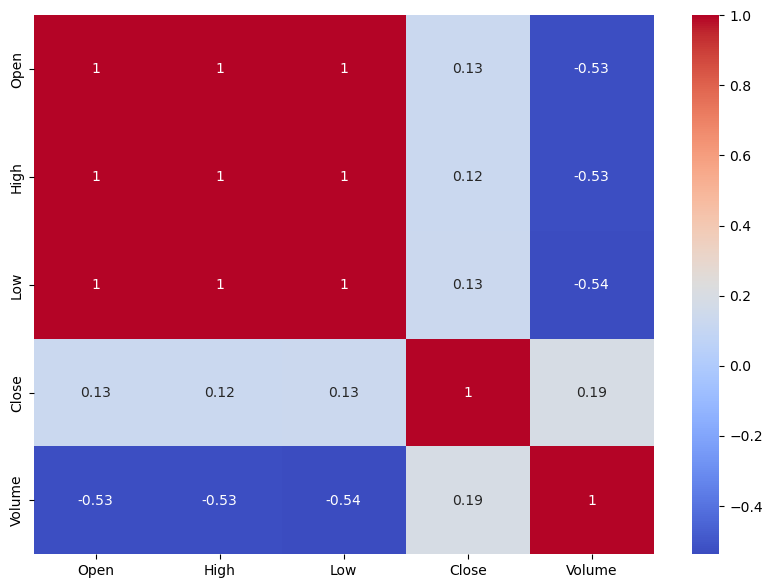

In [9]:
plt.figure(figsize=(10,7))
sns.heatmap(data.drop("Date", axis=1).corr(), annot=True, cmap="coolwarm")

plt.show()

In [10]:
scaled_data = scaled_data.drop([0, 2, 3], axis=1) 
scaled_data

,1,4
0,0.096401,0.295258
1,0.098344,0.229936
2,0.092517,0.263612
3,0.088819,0.216179
4,0.076718,0.467797
...,...,...
1253,0.955292,0.024650
1254,0.964853,0.031286
1255,0.958074,0.045891
1256,0.942574,0.029491


In [11]:
import numpy as np

def split_seq_multivariate(sequence, n_past, n_future):
    '''
    n_past  ==> number of past observations
    n_future ==> number of future observations
    '''
    
    x = []
    y = []
    
    for window_start in range(len(sequence)):
        past_end = window_start + n_past
        future_end = past_end + n_future
        
        if future_end > len(sequence):
            break
        
        # slicing the past and future parts
        past = sequence[window_start:past_end, :]
        future = sequence[past_end:future_end, -1]
        
        x.append(past)
        y.append(future)
    
    return np.array(x), np.array(y)

In [12]:
n_steps = 60
scaled_data = scaled_data.to_numpy() 
scaled_data.shape


(1258, 2)

In [13]:
x, y = split_seq_multivariate(scaled_data, n_steps, 1)

In [14]:
x.shape, y.shape

((1198, 60, 2), (1198, 1))

In [15]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

x_train.shape, x_test.shape, y_train.shape, y_test.shape


((958, 60, 2), (240, 60, 2), (958, 1), (240, 1))

In [16]:
model = Sequential()

model.add(LSTM(64, input_shape=(n_steps, 2)))
model.add(Dense(50, activation='relu'))
model.add(Dense(50, activation='relu'))
model.add(Dense(30, activation='relu'))
model.add(Dense(1))

C:\Users\Parth S Kourwar\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          17,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 50)                  │           3,250 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 50)                  │           2,550 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 30)                  │           1,530 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              31 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,513 (95.75 KB)

 Trainable params: 24,513 (95.75 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(optimizer='adam',  loss='mse',  metrics=['mae'])

In [19]:
history = model.fit(x_train, y_train, epochs=10, batch_size=32, verbose=1)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0092 - mae: 0.0600
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0044 - mae: 0.0380
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0044 - mae: 0.0396
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0043 - mae: 0.0370
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0042 - mae: 0.0357
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0041 - mae: 0.0350
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0041 - mae: 0.0355
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0041 - mae: 0.0359
Epoch 9/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0040 - mae: 0.0348
Epoch 10/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0040 - mae: 0.0355


<Axes: >

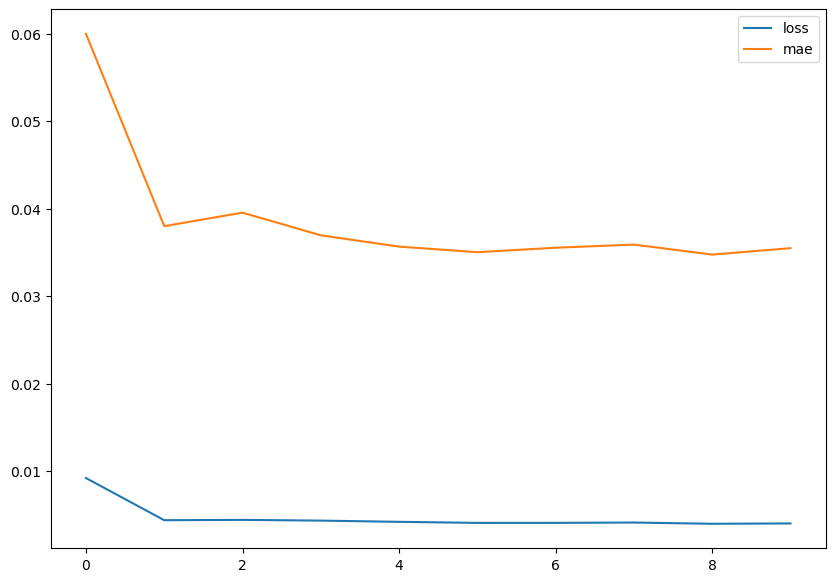

In [20]:
pd.DataFrame(history.history).plot(figsize=(10,7))

In [21]:
model.evaluate(x_test, y_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0046 - mae: 0.0396 


[0.004558064509183168, 0.03961659222841263]

In [22]:
predictions = model.predict(x_test) 
predictions.shape

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step 


(240, 1)

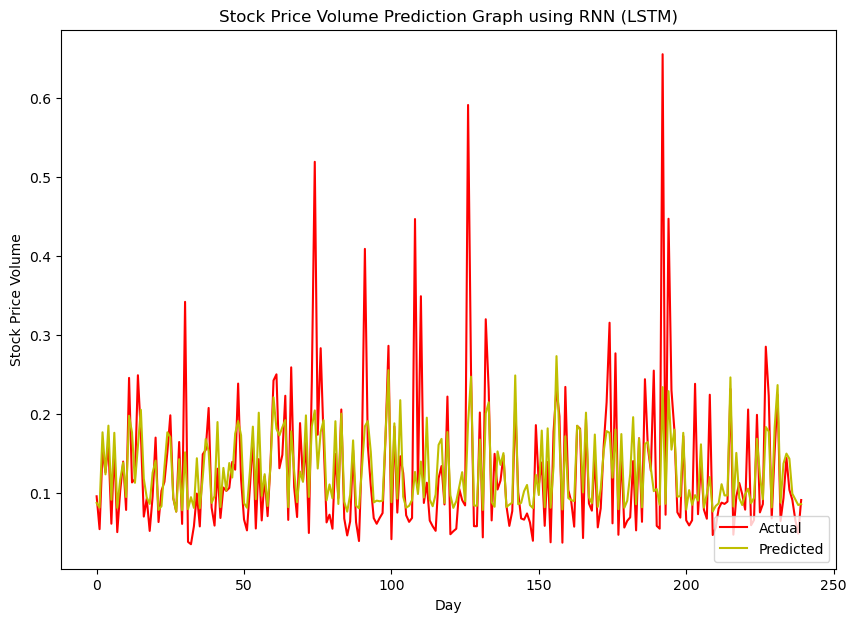

In [23]:
plt.figure(figsize=(10,7))

plt.plot(y_test, c='r')
plt.plot(predictions, c='y')

plt.xlabel('Day')
plt.ylabel('Stock Price Volume')
plt.title('Stock Price Volume Prediction Graph using RNN (LSTM)')

plt.legend(['Actual', 'Predicted'], loc='lower right')

plt.show()